In [1]:
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

In [2]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/home/adbhut/Desktop/study_material/datatalks-club/mlops-zoomcamp/week_2/mlruns/1', creation_time=1781357233763, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781357233763, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

In [3]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [4]:
def read_dataframe(df_path):
    df = pd.read_parquet(df_path)

    df["duration"] = (
        df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]
    )
    df["duration"] = df["duration"].apply(lambda x: x.total_seconds() / 60)

    df = df[(df["duration"] > 2) & (df["duration"] <= 60)]
    print(f"Loaded {len(df)} rows from {df_path}")

    return df

In [5]:
jan_df = read_dataframe("../data/green_tripdata_2026-01.parquet")
feb_df = read_dataframe("../data/green_tripdata_2026-02.parquet")

Loaded 37767 rows from ../data/green_tripdata_2026-01.parquet
Loaded 35023 rows from ../data/green_tripdata_2026-02.parquet


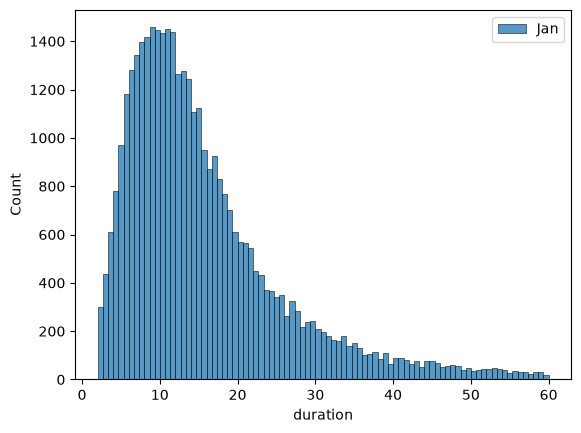

In [6]:
sns.histplot(jan_df["duration"], label="Jan")
plt.legend()

In [7]:
categorical_features = ["PULocationID", "DOLocationID"]
numerical_features = ["trip_distance"]

jan_df[categorical_features] = jan_df[categorical_features].astype(str)
feb_df[categorical_features] = feb_df[categorical_features].astype(str)

In [8]:
jan_df["PU_DO"] = jan_df["PULocationID"] + "_" + jan_df["DOLocationID"]
feb_df["PU_DO"] = feb_df["PULocationID"] + "_" + feb_df["DOLocationID"]

In [9]:
categorical_features = ["PU_DO", "PULocationID", "DOLocationID"]
numerical_features = ["trip_distance"]

dv = DictVectorizer()


train_dicts = (
    jan_df[categorical_features + numerical_features]
    .to_dict(orient="records")
)
X_train = dv.fit_transform(train_dicts)

val_dicts = (
    feb_df[categorical_features + numerical_features]
    .to_dict(orient="records")
)
X_val = dv.transform(val_dicts)

In [10]:
target = "duration"

y_train = jan_df[target]
y_val = feb_df[target]

In [ ]:
with mlflow.start_run():
    mlflow.set_tag("developer", "adbhut")

    mlflow.log_param("train-data-path", "data/green_tripdata_2026-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2026-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Ridge(alpha=alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("RMSE", rmse)

In [12]:
xgb_train = xgb.DMatrix(X_train, label=y_train)
xgb_val = xgb.DMatrix(X_val, label=y_val)

In [13]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params=params)

        booster = xgb.train(
            params=params,
            dtrain=xgb_train,
            num_boost_round=1000,
            evals=[(xgb_val, "validation")],
            early_stopping_rounds=50,
        )
        y_pred = booster.predict(xgb_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("RMSE", rmse)

    return {"loss": rmse, "status": STATUS_OK}

In [14]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:squarederror',
    'seed': 42
}


best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

[0]	validation-rmse:7.16249                           
[1]	validation-rmse:6.38591                           
[2]	validation-rmse:6.23050                           
[3]	validation-rmse:6.18696                           
[4]	validation-rmse:6.17586                           
[5]	validation-rmse:6.16887                           
[6]	validation-rmse:6.16925                           
[7]	validation-rmse:6.16929                           
[8]	validation-rmse:6.17038                           
[9]	validation-rmse:6.17207                           
[10]	validation-rmse:6.17208                          
[11]	validation-rmse:6.17091                          
[12]	validation-rmse:6.16363                          
[13]	validation-rmse:6.16376                          
[14]	validation-rmse:6.16749                          
[15]	validation-rmse:6.16828                          
[16]	validation-rmse:6.17171                          
[17]	validation-rmse:6.17360                          
[18]	valid

In [15]:
params = {
    "learning_rate": 0.0722808411558041,
    "max_depth": 11,
    "min_child_weight": 7.142735631488048,
    "objective": "reg:squarederror",
    "reg_alpha": 0.07936041950544223,
    "reg_lambda": 0.009486350858610174,
    "seed": 42,
}

mlflow.xgboost.autolog()

booster = xgb.train(
    params=params,
    dtrain=xgb_train,
    num_boost_round=1000,
    evals=[(xgb_val, "validation")],
    early_stopping_rounds=50,
)

2026/06/14 16:08:27 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '67a3fded64fd469b95e8bbd5ecd0ec3d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:9.85746
[1]	validation-rmse:9.42998
[2]	validation-rmse:9.04567
[3]	validation-rmse:8.70053
[4]	validation-rmse:8.39181
[5]	validation-rmse:8.11437
[6]	validation-rmse:7.86721
[7]	validation-rmse:7.64562
[8]	validation-rmse:7.44940
[9]	validation-rmse:7.27544
[10]	validation-rmse:7.12231
[11]	validation-rmse:6.98625
[12]	validation-rmse:6.86530
[13]	validation-rmse:6.75677
[14]	validation-rmse:6.66147
[15]	validation-rmse:6.57917
[16]	validation-rmse:6.50639
[17]	validation-rmse:6.44150
[18]	validation-rmse:6.38553
[19]	validation-rmse:6.33496
[20]	validation-rmse:6.28926
[21]	validation-rmse:6.25042
[22]	validation-rmse:6.21582
[23]	validation-rmse:6.18556
[24]	validation-rmse:6.15895
[25]	validation-rmse:6.13440
[26]	validation-rmse:6.11248
[27]	validation-rmse:6.09249
[28]	validation-rmse:6.07473
[29]	validation-rmse:6.05878
[30]	validation-rmse:6.04478
[31]	validation-rmse:6.03019
[32]	validation-rmse:6.01829
[33]	validation-rmse:6.00787
[34]	validation-rmse:5.9

2026/06/14 16:11:19 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/06/14 16:11:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/14 16:11:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### Model management

In [14]:
with mlflow.start_run():
    mlflow.set_tag("developer", "adbhut")

    mlflow.log_param("train-data-path", "data/green_tripdata_2026-01.parquet")
    mlflow.log_param("val-data-path", "data/green_tripdata_2026-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Ridge(alpha=alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("RMSE", rmse)

    with open("./models/ridge.bin", "wb") as f:
        pickle.dump((dv, lr), f)

    mlflow.log_artifact(
        local_path="./models/ridge.bin",
        artifact_path="models_pickle"
    )

In [16]:
xgb_train = xgb.DMatrix(X_train, label=y_train)
xgb_val = xgb.DMatrix(X_val, label=y_val)

In [19]:
with mlflow.start_run():
    params = {
        "learning_rate": 0.0722808411558041,
        "max_depth": 11,
        "min_child_weight": 7.142735631488048,
        "objective": "reg:squarederror",
        "reg_alpha": 0.07936041950544223,
        "reg_lambda": 0.009486350858610174,
        "seed": 42,
    }

    mlflow.log_params(params)

    booster = xgb.train(
        params=params,
        dtrain=xgb_train,
        num_boost_round=1000,
        evals=[(xgb_val, "validation")],
        early_stopping_rounds=50,
    )

    with open("./models/preprocessor.bin", "wb") as f:
          pickle.dump(dv, f)

    mlflow.log_artifact("./models/preprocessor.bin", artifact_path="preprocessor")
    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

[0]	validation-rmse:9.85746
[1]	validation-rmse:9.42998
[2]	validation-rmse:9.04567
[3]	validation-rmse:8.70053
[4]	validation-rmse:8.39181
[5]	validation-rmse:8.11437
[6]	validation-rmse:7.86721
[7]	validation-rmse:7.64562
[8]	validation-rmse:7.44940
[9]	validation-rmse:7.27544
[10]	validation-rmse:7.12231
[11]	validation-rmse:6.98625
[12]	validation-rmse:6.86530
[13]	validation-rmse:6.75677
[14]	validation-rmse:6.66147
[15]	validation-rmse:6.57917
[16]	validation-rmse:6.50639
[17]	validation-rmse:6.44150
[18]	validation-rmse:6.38553
[19]	validation-rmse:6.33496
[20]	validation-rmse:6.28926
[21]	validation-rmse:6.25042
[22]	validation-rmse:6.21582
[23]	validation-rmse:6.18556
[24]	validation-rmse:6.15895
[25]	validation-rmse:6.13440
[26]	validation-rmse:6.11248
[27]	validation-rmse:6.09249
[28]	validation-rmse:6.07473
[29]	validation-rmse:6.05878
[30]	validation-rmse:6.04478
[31]	validation-rmse:6.03019
[32]	validation-rmse:6.01829
[33]	validation-rmse:6.00787
[34]	validation-rmse:5.9

2026/06/16 15:24:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 15:24:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [20]:
logged_model = (
    "/home/adbhut/Desktop/study_material/datatalks-club/mlops-zoomcamp/week_2"
    + "/mlruns/1/models/m-a53d4197d42947cfac4415c9e65efe1b/artifacts"
)

model = mlflow.pyfunc.load_model(logged_model)

In [22]:
model

mlflow.pyfunc.loaded_model:
  artifact_path: /home/adbhut/Desktop/study_material/datatalks-club/mlops-zoomcamp/week_2/mlruns/1/models/m-a53d4197d42947cfac4415c9e65efe1b/artifacts
  flavor: mlflow.xgboost
  run_id: 58cc12a6e35a41baa56e08ea846034e8

In [28]:
y_pred = model.predict(X_val)
y_pred[:5]

array([ 5.39161 ,  7.897159, 20.15927 , 18.3974  , 14.857147],
      dtype=float32)

In [23]:
xgboost_model = mlflow.xgboost.load_model(logged_model)

In [24]:
xgboost_model

In [27]:
y_pred = xgboost_model.predict(xgb_val)
y_pred[:5]

array([ 5.39161 ,  7.897159, 20.15927 , 18.3974  , 14.857147],
      dtype=float32)